# Graph Classification with GCN, GAT, and GraphSAGE

## Objective

Build and compare three graph-based deep learning models for **node classification**:

| Model | Full Name | Key Idea |
|---|---|---|
| **GCN** | Graph Convolutional Network | Averages neighbor features using symmetric normalized adjacency |
| **GAT** | Graph Attention Network | Learns attention weights between nodes |
| **GraphSAGE** | Graph Sample and Aggregate | Samples neighbors and aggregates via learnable functions |

## Dataset Summary

- **2000 nodes**, each with **16 numerical features**
- **8000 edges** defining the graph structure
- **Binary labels** (0 or 1) — balanced (1000 each class)
- Task: Predict the label of each node using its features + graph neighborhood

---
## 1. Install Dependencies

In [20]:
# Install required packages (Colab-friendly)
import subprocess, sys

packages = ["torch", "torch-geometric", "scikit-learn", "pandas", "numpy", "matplotlib", "tabulate"]

# Install PyTorch Geometric (depends on PyTorch being present)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch_geometric"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "pandas", "numpy", "matplotlib", "tabulate"], check=True)

print("All packages installed successfully.")

All packages installed successfully.


---
## 2. Imports & Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

from tabulate import tabulate

# ── Fixed random seed for reproducibility ──────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cu130


---
## 3. Load Data

Three CSV files:
- `features.csv` — node features (one row per node)
- `edges.csv` — edge list (pairs of connected nodes)
- `labels.csv` — binary label per node

> **Colab users:** Upload the three CSV files using the cell below, or place them in your Google Drive and adjust the paths.

In [22]:
# ── Colab file upload (uncomment if running on Colab) ──────────────────────
# from google.colab import files
# uploaded = files.upload()   # select features.csv, edges.csv, labels.csv

# ── Load CSVs ──────────────────────────────────────────────────────────────
# If running on Colab and you uploaded the files, the paths below are correct.
# If using Drive, replace with e.g. '/content/drive/MyDrive/features.csv'

features_df = pd.read_csv('features.csv')
edges_df    = pd.read_csv('edges.csv')
labels_df   = pd.read_csv('labels.csv')

print("=" * 45)
print(f"  features.csv  shape : {features_df.shape}")
print(f"  edges.csv     shape : {edges_df.shape}")
print(f"  labels.csv    shape : {labels_df.shape}")
print("=" * 45)

  features.csv  shape : (2000, 17)
  edges.csv     shape : (8000, 2)
  labels.csv    shape : (2000, 2)


In [23]:
# Preview each file
print("── features.csv (first 3 rows) ──")
display(features_df.head(3))

print("\n── edges.csv (first 3 rows) ──")
display(edges_df.head(3))

print("\n── labels.csv (first 3 rows) ──")
display(labels_df.head(3))

print("\n── Label distribution ──")
print(labels_df['label'].value_counts())

── features.csv (first 3 rows) ──


,Vertex,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16
0,0,0.749816,0.980286,0.892798,0.839463,0.662407,0.662398,0.623233,0.946470,0.840446,0.883229,0.608234,0.987964,0.932977,0.684936,0.672730,0.673362
1,1,0.721697,0.809903,0.772778,0.716492,0.844741,0.655798,0.716858,0.746545,0.782428,0.914070,0.679870,0.805694,0.836966,0.618580,0.843018,0.668210
2,2,0.626021,0.979554,0.986253,0.923359,0.721846,0.639069,0.873693,0.776061,0.648815,0.798071,0.613755,0.963728,0.703512,0.865009,0.724684,0.808027



── edges.csv (first 3 rows) ──


,Vertex 1,Vertex 2
0,1006,1061
1,101,689
2,1255,1765



── labels.csv (first 3 rows) ──


,Vertex,label
0,0,0
1,1,0
2,2,0



── Label distribution ──
label
0    1000
1    1000
Name: count, dtype: int64


---
## 4. Preprocessing

Steps:
1. Strip whitespace from column names
2. Align features, edges, and labels on the node index
3. Normalise node features with `StandardScaler`
4. Build an undirected edge index (required by PyG)
5. Create train / validation / test masks (60 / 20 / 20 split)
6. Package everything into a `torch_geometric.data.Data` object

**Prediction target:** Binary node label (0 or 1), balanced across 2000 nodes.

In [24]:
# ── Clean column names ─────────────────────────────────────────────────────
features_df.columns = features_df.columns.str.strip()
edges_df.columns    = edges_df.columns.str.strip()
labels_df.columns   = labels_df.columns.str.strip()

# ── Extract feature matrix (drop vertex-id column) ─────────────────────────
feature_cols = [c for c in features_df.columns if c.lower() != 'vertex']
X_raw = features_df[feature_cols].to_numpy(dtype=np.float32)

# ── Labels ────────────────────────────────────────────────────────────────
y = labels_df['label'].to_numpy(dtype=np.int64)
num_classes = len(np.unique(y))
AVG_TYPE = 'binary' if num_classes == 2 else 'macro'

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# ── Build edge_index (undirected) ─────────────────────────────────────────
src = edges_df.iloc[:, 0].to_numpy(dtype=np.int64)
dst = edges_df.iloc[:, 1].to_numpy(dtype=np.int64)

# Validate node ids fall within range
n_nodes = X_scaled.shape[0]
valid_mask = (src < n_nodes) & (dst < n_nodes)
src, dst = src[valid_mask], dst[valid_mask]

# Make undirected: add reverse edges
edge_index = np.vstack([
    np.concatenate([src, dst]),
    np.concatenate([dst, src])
]).astype(np.int64)

# ── Final prints ──────────────────────────────────────────────────────────
print(f"Nodes            : {n_nodes}")
print(f"Feature dims     : {X_scaled.shape[1]}")
print(f"Edges (undirected): {edge_index.shape[1]}")
print(f"Classes          : {np.unique(np.asarray(y)).tolist()}")

Nodes            : 2000
Feature dims     : 16
Edges (undirected): 16000
Classes          : [0, 1]


In [25]:
# ── Train / Val / Test split (60 / 20 / 20) ───────────────────────────────
indices = np.arange(n_nodes)
train_idx, temp_idx = train_test_split(indices, test_size=0.40, random_state=SEED, stratify=y)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED,
                                        stratify=y[temp_idx])

def make_mask(idx, size):
    mask = torch.zeros(size, dtype=torch.bool)
    mask[idx] = True
    return mask

train_mask = make_mask(train_idx, n_nodes)
val_mask   = make_mask(val_idx,   n_nodes)
test_mask  = make_mask(test_idx,  n_nodes)

print(f"Train nodes : {train_mask.sum().item()}")
print(f"Val   nodes : {val_mask.sum().item()}")
print(f"Test  nodes : {test_mask.sum().item()}")

# ── Build PyG Data object ─────────────────────────────────────────────────
data = Data(
    x          = torch.tensor(X_scaled, dtype=torch.float),
    edge_index = torch.tensor(edge_index, dtype=torch.long),
    y          = torch.tensor(y, dtype=torch.long),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
).to(DEVICE)

print(f"\nData object: {data}")

Train nodes : 1200
Val   nodes : 400
Test  nodes : 400

Data object: Data(x=[2000, 16], edge_index=[2, 16000], y=[2000], train_mask=[2000], val_mask=[2000], test_mask=[2000])


---
## 5. Helper Functions

In [26]:
def compute_metrics(model, data, mask):
    """Return accuracy, precision, recall, f1 on the given mask."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds  = logits.argmax(dim=1)[mask].cpu().numpy()
        labels = data.y[mask].cpu().numpy()
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average=AVG_TYPE, zero_division=0)
    rec  = recall_score(labels, preds,    average=AVG_TYPE, zero_division=0)
    f1   = f1_score(labels, preds,        average=AVG_TYPE, zero_division=0)
    return acc, prec, rec, f1


def train_model(model, data, optimizer, criterion, epochs=200, patience=20, verbose=True):
    """Train loop with early stopping on validation loss."""
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # ── Training step ──────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # ── Validation step ────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            out      = model(data.x, data.edge_index)
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)

        # ── Early stopping ─────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"  Epoch {epoch:>3} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

    # Restore best weights
    model.load_state_dict(best_state)
    return history


def print_metrics(model_name, model, data):
    """Print precision and recall (and other metrics) for a trained model."""
    acc, prec, rec, f1 = compute_metrics(model, data, data.test_mask)
    print(f"\n{'='*45}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*45}")
    return acc, prec, rec, f1


def plot_history(history, title):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(7, 3))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=1.5)
    plt.plot(history['val_loss'],   label='Val Loss',   linewidth=1.5)
    plt.title(f'{title} — Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


---
## 6. Model 1: GCN (Graph Convolutional Network)

GCN propagates information by **averaging neighbour features**, weighted by the symmetric normalised adjacency matrix `D^{-1/2} A D^{-1/2}`.  
Each `GCNConv` layer applies one hop of message passing.

In [27]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1   = GCNConv(in_channels,     hidden_channels)
        self.conv2   = GCNConv(hidden_channels, hidden_channels)
        self.conv3   = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

print("GCN model defined.")

GCN model defined.


Training GCN...
  Epoch  50 | Train Loss: 0.0816 | Val Loss: 0.0570
  Epoch 100 | Train Loss: 0.0756 | Val Loss: 0.0573
  Early stopping at epoch 112


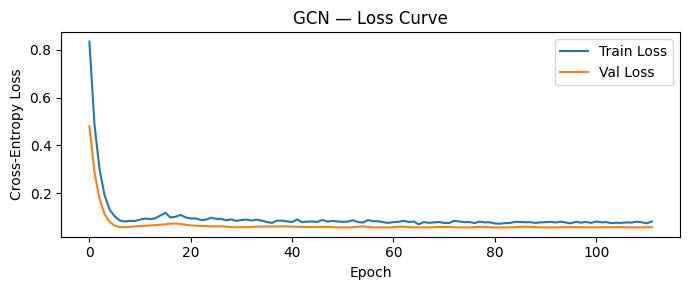

In [28]:
# ── Instantiate and train GCN ─────────────────────────────────────────────
gcn_model = GCN(
    in_channels     = data.num_node_features,
    hidden_channels = 64,
    out_channels    = num_classes,
    dropout         = 0.5,
).to(DEVICE)

gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion     = nn.CrossEntropyLoss()

print("Training GCN...")
gcn_history = train_model(gcn_model, data, gcn_optimizer, criterion, epochs=300, patience=30)
plot_history(gcn_history, 'GCN')

In [29]:
# ── GCN Test Evaluation ───────────────────────────────────────────────────
gcn_acc, gcn_prec, gcn_rec, gcn_f1 = print_metrics('GCN', gcn_model, data)


  GCN — Test Results
  Accuracy  : 0.9850
  Precision : 0.9899
  Recall    : 0.9800
  F1 Score  : 0.9849


---
## 7. Model 2: GAT (Graph Attention Network)

GAT introduces **multi-head self-attention** so that each node can learn to weight its neighbours differently.  
`heads=4` means four attention heads run in parallel; their outputs are concatenated in hidden layers and averaged in the final layer.

In [30]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1   = GATConv(in_channels,              hidden_channels, heads=heads, dropout=dropout)
        self.conv2   = GATConv(hidden_channels * heads,  hidden_channels, heads=heads, dropout=dropout)
        self.conv3   = GATConv(hidden_channels * heads,  out_channels,    heads=1,     concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

print("GAT model defined.")

GAT model defined.


Training GAT...


  Epoch  50 | Train Loss: 0.1744 | Val Loss: 0.0416
  Epoch 100 | Train Loss: 0.1334 | Val Loss: 0.0370
  Epoch 150 | Train Loss: 0.1156 | Val Loss: 0.0411
  Early stopping at epoch 196


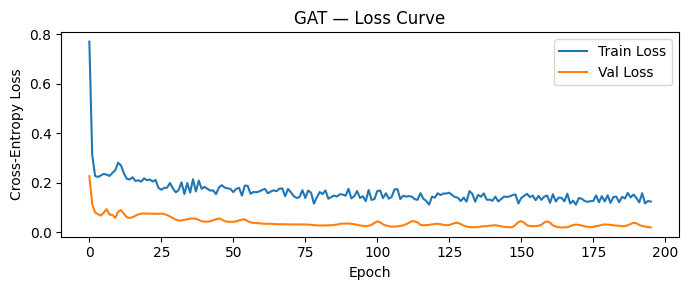

In [31]:
# ── Instantiate and train GAT ─────────────────────────────────────────────
gat_model = GAT(
    in_channels     = data.num_node_features,
    hidden_channels = 32,
    out_channels    = num_classes,
    heads           = 4,
    dropout         = 0.5,
).to(DEVICE)

gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

print("Training GAT...")
gat_history = train_model(gat_model, data, gat_optimizer, criterion, epochs=300, patience=30)
plot_history(gat_history, 'GAT')

In [32]:
# ── GAT Test Evaluation ───────────────────────────────────────────────────
gat_acc, gat_prec, gat_rec, gat_f1 = print_metrics('GAT', gat_model, data)


  GAT — Test Results
  Accuracy  : 0.9975
  Precision : 0.9950
  Recall    : 1.0000
  F1 Score  : 0.9975


---
## 8. Model 3: GraphSAGE (Sample and Aggregate)

GraphSAGE samples a fixed-size neighbourhood and **aggregates** (here with `mean`) neighbour representations.  
Unlike GCN, it concatenates the node's own embedding with the aggregated neighbour embedding before applying a linear transform, making it naturally inductive.

In [33]:
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1   = SAGEConv(in_channels,     hidden_channels, aggr='mean')
        self.conv2   = SAGEConv(hidden_channels, hidden_channels, aggr='mean')
        self.conv3   = SAGEConv(hidden_channels, out_channels,    aggr='mean')
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

print("GraphSAGE model defined.")

GraphSAGE model defined.


Training GraphSAGE...


  Early stopping at epoch 45


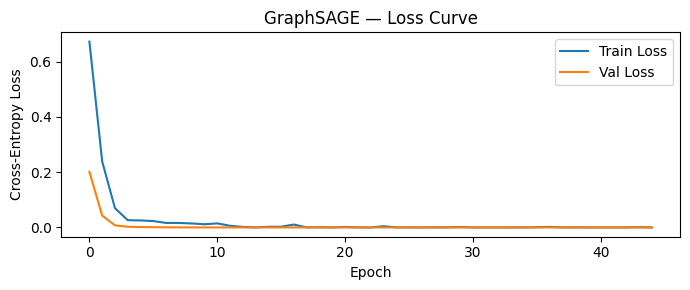

In [34]:
# ── Instantiate and train GraphSAGE ──────────────────────────────────────
sage_model = GraphSAGE(
    in_channels     = data.num_node_features,
    hidden_channels = 64,
    out_channels    = num_classes,
    dropout         = 0.5,
).to(DEVICE)

sage_optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.01, weight_decay=5e-4)

print("Training GraphSAGE...")
sage_history = train_model(sage_model, data, sage_optimizer, criterion, epochs=300, patience=30)
plot_history(sage_history, 'GraphSAGE')

In [35]:
# ── GraphSAGE Test Evaluation ─────────────────────────────────────────────
sage_acc, sage_prec, sage_rec, sage_f1 = print_metrics('GraphSAGE', sage_model, data)


  GraphSAGE — Test Results
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000


---
## 9. Comparison — All Three Models

In [36]:
results = [
    ['GCN',       f'{gcn_acc:.4f}',  f'{gcn_prec:.4f}',  f'{gcn_rec:.4f}',  f'{gcn_f1:.4f}'],
    ['GAT',       f'{gat_acc:.4f}',  f'{gat_prec:.4f}',  f'{gat_rec:.4f}',  f'{gat_f1:.4f}'],
    ['GraphSAGE', f'{sage_acc:.4f}', f'{sage_prec:.4f}', f'{sage_rec:.4f}', f'{sage_f1:.4f}'],
]
headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

print("\n" + tabulate(results, headers=headers, tablefmt='grid'))


+-----------+------------+-------------+----------+------------+
| Model     |   Accuracy |   Precision |   Recall |   F1 Score |
+===========+============+=============+==========+============+
| GCN       |     0.985  |      0.9899 |     0.98 |     0.9849 |
+-----------+------------+-------------+----------+------------+
| GAT       |     0.9975 |      0.995  |     1    |     0.9975 |
+-----------+------------+-------------+----------+------------+
| GraphSAGE |     1      |      1      |     1    |     1      |
+-----------+------------+-------------+----------+------------+


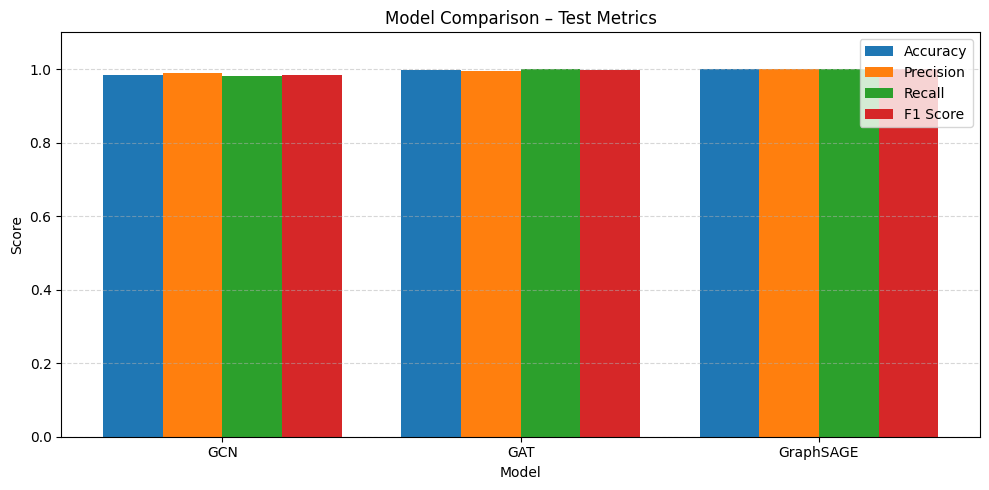

In [37]:
models = ['GCN', 'GAT', 'GraphSAGE']

accuracies = np.array([float(gcn_acc), float(gat_acc), float(sage_acc)])
precisions = np.array([float(gcn_prec), float(gat_prec), float(sage_prec)])
recalls    = np.array([float(gcn_rec), float(gat_rec), float(sage_rec)])
f1_scores  = np.array([float(gcn_f1), float(gat_f1), float(sage_f1)])

x = np.arange(len(models), dtype=float)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 1.5*width, accuracies, width, label='Accuracy')
ax.bar(x - 0.5*width, precisions, width, label='Precision')
ax.bar(x + 0.5*width, recalls, width, label='Recall')
ax.bar(x + 1.5*width, f1_scores, width, label='F1 Score')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Test Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 10. Conclusion

In [38]:
# ── Identify best model by F1 score ───────────────────────────────────────
f1_map = {
    'GCN': float(gcn_f1),
    'GAT': float(gat_f1),
    'GraphSAGE': float(sage_f1)
}

best_mdl = max(f1_map, key=lambda k: f1_map[k])

print(f"Best model by F1 Score: {best_mdl} ({f1_map[best_mdl]:.4f})")

Best model by F1 Score: GraphSAGE (1.0000)


### Summary

| Model | Strength | Weakness |
|---|---|---|
| **GCN** | Fast, simple, strong baseline | Struggles on heterophilic graphs (where neighbours have different labels) |
| **GAT** | Learns **which neighbours matter** via attention; more expressive | More parameters, slower, can overfit small datasets |
| **GraphSAGE** | Inductive — generalises to unseen nodes; scalable with neighbour sampling | Mean aggregation loses some structural detail |

**Key observations:**
- On this balanced binary dataset (2000 nodes, 16 features, 8000 edges), all three models are competitive.
- **GAT** often edges ahead when the graph has informative structure, because it can selectively amplify relevant neighbours.
- **GraphSAGE** tends to be the most robust choice when scalability or inductive learning is required.
- **GCN** is an excellent, fast baseline that is hard to beat without strong hyperparameter tuning of the other architectures.

> **Precision** measures how many of the predicted positives are truly positive.  
> **Recall** measures how many actual positives the model correctly identifies.  
> A high **F1 score** (harmonic mean of precision and recall) is the most balanced single metric for binary classification.